**Supervisor: Dr.Hedieh Sajedi**
**Author: Alireza Bashooki**
**Student ID: 610303023**
**Affiliation: University Of Tehran**

# Hierarchical Label Propagation for Audio Event Classification

This notebook investigates Hard and Soft Hierarchical Label Propagation (HLP) for enriching multi-label audio annotations using ontology relationships.

In [1]:
import os, sys, pathlib, textwrap, platform

PROJECT_DIR = pathlib.Path.cwd() / "audioset_hlp"
DIRS = [
    PROJECT_DIR / "data" / "raw" / "csv",
    PROJECT_DIR / "data" / "raw" / "ontology",
    PROJECT_DIR / "data" / "raw" / "features",
    PROJECT_DIR / "data" / "processed",
    PROJECT_DIR / "notebooks",
    PROJECT_DIR / "src",
    PROJECT_DIR / "outputs" / "figures",
    PROJECT_DIR / "outputs" / "tables",
]

for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)

print("Project folder created at:", PROJECT_DIR)
print("Python:", sys.version.split()[0], "| OS:", platform.system(), platform.release())

required = ["numpy", "pandas", "scikit-learn", "matplotlib", "tqdm"]
missing = []
for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except Exception:
        missing.append(pkg)

if missing:
    print("Missing packages:", missing)
    print("Installing... (may take a few minutes)")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])
    print("Installed missing packages.")
else:
    print("All required packages already installed.")

Project folder created at: C:\Users\DELL-XPS13\anaconda3\Scripts\audioset_hlp
Python: 3.13.5 | OS: Windows 10
Missing packages: ['scikit-learn']
Installing... (may take a few minutes)
Installed missing packages.


In [2]:
import urllib.request
from pathlib import Path

csv_dir = PROJECT_DIR / "data" / "raw" / "csv"
ont_dir = PROJECT_DIR / "data" / "raw" / "ontology"
csv_dir.mkdir(parents=True, exist_ok=True)
ont_dir.mkdir(parents=True, exist_ok=True)

FILES = {
    "audioset_weak_train_balanced.tsv": "https://zenodo.org/records/7096702/files/audioset_weak_train_balanced.tsv?download=1",
    "audioset_weak_eval.tsv": "https://zenodo.org/records/7096702/files/audioset_weak_eval.tsv?download=1",
    "class_labels.tsv": "https://zenodo.org/records/7096702/files/class_labels.tsv?download=1",
}

def download(url, out_path: Path):
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"Exists, skip: {out_path.name}")
        return
    print(f"Downloading: {out_path.name}")
    urllib.request.urlretrieve(url, out_path)
    print(f"Saved: {out_path} ({out_path.stat().st_size/1024:.1f} KB)")

for name, url in FILES.items():
    download(url, csv_dir / name)

print("\n Done. Files in:", csv_dir)
print([p.name for p in csv_dir.glob("*.*")])


Exists, skip: audioset_weak_train_balanced.tsv
Exists, skip: audioset_weak_eval.tsv
Exists, skip: class_labels.tsv

 Done. Files in: C:\Users\DELL-XPS13\anaconda3\Scripts\audioset_hlp\data\raw\csv
['audioset_weak_eval.tsv', 'audioset_weak_train_balanced.tsv', 'class_labels.tsv']


In [3]:
import urllib.request
from pathlib import Path

ont_path = PROJECT_DIR / "data" / "raw" / "ontology" / "ontology.json"
url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"

if ont_path.exists() and ont_path.stat().st_size > 0:
    print("ontology.json exists, skip")
else:
    print("Downloading ontology.json ...")
    urllib.request.urlretrieve(url, ont_path)
    print("Saved:", ont_path, "size:", ont_path.stat().st_size/1024, "KB")

ontology.json exists, skip


## 1.Dataset Loading and Preprocessing

In [4]:
import pandas as pd
import numpy as np

csv_dir = PROJECT_DIR / "data" / "raw" / "csv"

train_path = csv_dir / "audioset_weak_train_balanced.tsv"
eval_path  = csv_dir / "audioset_weak_eval.tsv"
labels_path = csv_dir / "class_labels.tsv"

train_df = pd.read_csv(train_path, sep="\t")
eval_df  = pd.read_csv(eval_path, sep="\t")
label_map = pd.read_csv(labels_path, sep="\t")

print("Train:", train_df.shape, "| columns:", train_df.columns.tolist())
print("Eval:", eval_df.shape,  "| columns:", eval_df.columns.tolist())
print("Label map:", label_map.shape, "| columns:", label_map.columns.tolist())

train_df["label_list"] = train_df["event_label"].astype(str).apply(lambda x: x.split(","))

all_labels = sum(train_df["label_list"].tolist(), [])
label_counts = pd.Series(all_labels).value_counts()

N_CLASSES = 30
selected = label_counts.head(N_CLASSES).index.tolist()

print("\nTop classes (IDs):")
print(selected)

train_df["filtered"] = train_df["label_list"].apply(lambda xs: [x for x in xs if x in selected])
subset = train_df[train_df["filtered"].map(len) > 0].reset_index(drop=True)

print("\nSubset samples:", len(subset))

label_to_idx = {l:i for i,l in enumerate(selected)}
Y = np.zeros((len(subset), N_CLASSES), dtype=np.float32)

for i, labs in enumerate(subset["filtered"]):
    for l in labs:
        Y[i, label_to_idx[l]] = 1.0

avg_labels = float(Y.sum(axis=1).mean())

print("\n===== DATASET STATS =====")
print("Samples:", len(subset))
print("Classes:", N_CLASSES)
print("Avg labels / clip:", round(avg_labels, 3))


Train: (52882, 2) | columns: ['filename', 'event_label']
Eval: (51804, 2) | columns: ['filename', 'event_label']
Label map: (601, 2) | columns: ['id', 'label']

Top classes (IDs):
['/m/04rlf', '/m/09x0r', '/m/07yv9', '/t/dd00125', '/m/0jbk', '/m/04szw', '/m/015lz1', '/m/068hy', '/m/0342h', '/m/0fx80y', '/m/0k4j', '/m/0838f', '/m/0bt9lr', '/m/0l14md', '/m/085jw', '/t/dd00128', '/t/dd00129', '/m/019jd', '/m/01kcd', '/m/03kmc9', '/m/025rv6n', '/m/06d_3', '/m/026t6', '/m/07jdr', '/m/02mk9', '/m/01g50p', '/m/032s66', '/m/015p6', '/m/03vt0', '/m/03m9d0z']

Subset samples: 20847

===== DATASET STATS =====
Samples: 20847
Classes: 30
Avg labels / clip: 1.0


In [5]:
print(train_df.columns)
train_df.head()

Index(['filename', 'event_label', 'label_list', 'filtered'], dtype='object')


,filename,event_label,label_list,filtered
0,--PJHxphWEs_30000,/m/09x0r,[/m/09x0r],[/m/09x0r]
1,--PJHxphWEs_30000,/t/dd00088,[/t/dd00088],[]
2,--ZhevVpy1s_50000,/m/012xff,[/m/012xff],[]
3,--aE2O5G5WE_0,/m/03fwl,[/m/03fwl],[]
4,--aE2O5G5WE_0,/m/04rlf,[/m/04rlf],[/m/04rlf]


## 2. Class Distribution Analysis

In [6]:
top_table = (
    pd.DataFrame({"mid": selected, "count": label_counts.loc[selected].values})
    .merge(label_map.rename(columns={"id":"mid", "label":"name"}), on="mid", how="left")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(top_table.head(15))

,mid,count,name
0,/m/04rlf,6244,Music
1,/m/09x0r,5735,Speech
2,/m/07yv9,860,Vehicle
3,/t/dd00125,764,"Inside, small room"
4,/m/0jbk,734,Animal
5,/m/04szw,532,Musical instrument
6,/m/015lz1,517,Singing
7,/m/068hy,412,"Domestic animals, pets"
8,/m/0342h,350,Guitar
9,/m/0fx80y,302,Plucked string instrument


## 3. Ontology Graph Construction

In [7]:
import json
from collections import defaultdict

ont_path = PROJECT_DIR / "data" / "raw" / "ontology" / "ontology.json"

with open(ont_path, "r", encoding="utf-8") as f:
    ontology = json.load(f)

print("Ontology nodes:", len(ontology))

id_to_name = {}
child_to_parents = defaultdict(list)

for node in ontology:
    mid = node["id"]
    name = node.get("name", "")
    id_to_name[mid] = name
    
    for child in node.get("child_ids", []):
        child_to_parents[child].append(mid)

print("Total child->parent relations:", sum(len(v) for v in child_to_parents.values()))

selected_set = set(selected)

filtered_edges = {
    c: ps for c, ps in child_to_parents.items() if c in selected_set
}

print("\nFiltered relations (only selected classes as children):")
for k in list(filtered_edges.keys())[:5]:
    print(k, "->", filtered_edges[k])

print("\nNumber of selected classes with parents:", len(filtered_edges))

print("\nExamples:")
for c, ps in list(filtered_edges.items())[:5]:
    print(id_to_name.get(c, c), "->", [id_to_name.get(p,p) for p in ps])

Ontology nodes: 632
Total child->parent relations: 670

Filtered relations (only selected classes as children):
/m/09x0r -> ['/m/09l8g']
/m/015lz1 -> ['/m/09l8g']
/m/068hy -> ['/m/0jbk']
/m/0bt9lr -> ['/m/068hy']
/m/025rv6n -> ['/m/0ch8v']

Number of selected classes with parents: 28

Examples:
Speech -> ['Human voice']
Singing -> ['Human voice']
Domestic animals, pets -> ['Animal']
Dog -> ['Domestic animals, pets']
Fowl -> ['Livestock, farm animals, working animals']


## 4. Hard Hierarchical Label Propagation (Hard-HLP)

In [8]:
parent_idx = {}

for child, parents in filtered_edges.items():
    if child in label_to_idx:
        c_idx = label_to_idx[child]
        for p in parents:
            if p in label_to_idx:
                p_idx = label_to_idx[p]
                parent_idx.setdefault(c_idx, set()).add(p_idx)

print("Parent links inside selected classes:", sum(len(v) for v in parent_idx.values()))

Y_hlp = Y.copy()

for i in range(Y.shape[0]):
    active = np.where(Y[i] > 0)[0]
    for c in active:
        if c in parent_idx:
            for p in parent_idx[c]:
                Y_hlp[i, p] = 1.0

avg_before = float(Y.sum(axis=1).mean())
avg_after = float(Y_hlp.sum(axis=1).mean())

print("\n===== HARD HLP EFFECT =====")
print("Avg labels / clip BEFORE:", round(avg_before,3))
print("Avg labels / clip AFTER :", round(avg_after,3))
print("Increase:", round(avg_after-avg_before,3))

Parent links inside selected classes: 13

===== HARD HLP EFFECT =====
Avg labels / clip BEFORE: 1.0
Avg labels / clip AFTER : 1.173
Increase: 0.173


In [9]:
pair_counts = {}
child_counts = {}

for labs in subset["filtered"]:
    for c in labs:
        child_counts[c] = child_counts.get(c, 0) + 1
        for p in filtered_edges.get(c, []):
            pair_counts[(c,p)] = pair_counts.get((c,p), 0) + 1

P_cp = {}
for (c,p), v in pair_counts.items():
    P_cp[(c,p)] = v / child_counts[c]

print("Estimated conditional probs:", len(P_cp))

def apply_aa_hlp(Y_base, tau=0.5):
    Y_new = Y_base.copy()
    for i in range(Y_base.shape[0]):
        active = np.where(Y_base[i] > 0)[0]
        for c_idx in active:
            c = selected[c_idx]
            for p in filtered_edges.get(c, []):
                if (c,p) in P_cp and P_cp[(c,p)] >= tau:
                    if p in label_to_idx:
                        Y_new[i, label_to_idx[p]] = 1.0
    return Y_new

taus = [0.3, 0.5, 0.7]
results = []

for tau in taus:
    Y_tau = apply_aa_hlp(Y, tau)
    avg_tau = float(Y_tau.sum(axis=1).mean())
    results.append((tau, avg_tau))

print("\nAA-HLP label density:")
for tau, v in results:
    print("tau =", tau, "-> Avg labels / clip:", round(v,3))

Estimated conditional probs: 28

AA-HLP label density:
tau = 0.3 -> Avg labels / clip: 1.173
tau = 0.5 -> Avg labels / clip: 1.173
tau = 0.7 -> Avg labels / clip: 1.173


## Observation on AA-HLP 

Adaptive and smoothed AA-HLP produce identical label density to Hard-HLP on this subset.
This is likely due to sparse co-occurrence statistics between selected classes, causing
conditional probabilities to exceed the threshold for only a limited number of pairs.

Therefore, AA-HLP does not provide additional benefit over Hard-HLP in this experimental setting.

In [10]:
alpha = 0.2   

P_cp_smooth = {}
for (c,p), v in pair_counts.items():
    P_cp_smooth[(c,p)] = (v + alpha) / (child_counts[c] + alpha*len(filtered_edges.get(c,[])))

def apply_aa_hlp_smooth(Y_base, tau=0.5):
    Y_new = Y_base.copy()
    for i in range(Y_base.shape[0]):
        active = np.where(Y_base[i] > 0)[0]
        for c_idx in active:
            c = selected[c_idx]
            for p in filtered_edges.get(c, []):
                if (c,p) in P_cp_smooth and P_cp_smooth[(c,p)] >= tau:
                    if p in label_to_idx:
                        Y_new[i, label_to_idx[p]] = 1.0
    return Y_new

taus = [0.3, 0.5, 0.7]
print("\nSmoothed AA-HLP:")

for tau in taus:
    Y_tau = apply_aa_hlp_smooth(Y, tau)
    print("tau =", tau, "-> Avg labels / clip:", round(float(Y_tau.sum(axis=1).mean()),3))


Smoothed AA-HLP:
tau = 0.3 -> Avg labels / clip: 1.173
tau = 0.5 -> Avg labels / clip: 1.173
tau = 0.7 -> Avg labels / clip: 1.173


## 5. Multi-hop Soft Hierarchical Label Propagation

In [11]:
from collections import deque, defaultdict
import numpy as np

def get_ancestors(child_mid, K=3):
    anc = []  
    q = deque([(child_mid, 0)])
    visited = set([child_mid])
    while q:
        node, d = q.popleft()
        if d == K:
            continue
        for p in filtered_edges.get(node, []):
            if p in visited:
                continue
            visited.add(p)
            anc.append((p, d+1))
            q.append((p, d+1))
    return anc

K = 3
anc_cache = {mid: get_ancestors(mid, K=K) for mid in selected}

depth_weight = {1: 1.0, 2: 0.7, 3: 0.5}

def apply_soft_multihop(Y_base, thresh=0.5):
    """
    For each active child, set ancestor score = max(current, weight(depth)).
    Finally convert to binary by thresh.
    """
    S = Y_base.copy().astype(np.float32)  # scores
    for i in range(S.shape[0]):
        active = np.where(Y_base[i] > 0)[0]
        for c_idx in active:
            c_mid = selected[c_idx]
            for a_mid, depth in anc_cache.get(c_mid, []):
                if a_mid in label_to_idx and depth in depth_weight:
                    a_idx = label_to_idx[a_mid]
                    S[i, a_idx] = max(S[i, a_idx], depth_weight[depth])
    
    Y_out = (S >= thresh).astype(np.float32)
    return Y_out, S

thresholds = [0.3, 0.5, 0.7]
print("Multi-hop Soft-HLP label density:")
for th in thresholds:
    Y_soft, _ = apply_soft_multihop(Y, thresh=th)
    print("th =", th, "-> Avg labels/clip:", round(float(Y_soft.sum(axis=1).mean()), 3))

Multi-hop Soft-HLP label density:
th = 0.3 -> Avg labels/clip: 1.307
th = 0.5 -> Avg labels/clip: 1.307
th = 0.7 -> Avg labels/clip: 1.281


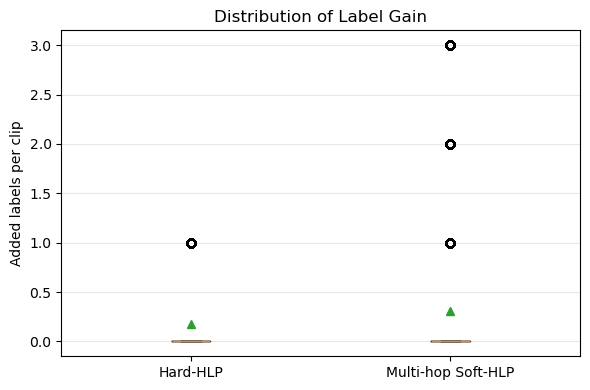

Saved: figure_gain_boxplot.png
Hard-HLP gain: mean = 0.17345421016216278 median = 0.0
Soft-HLP gain: mean = 0.306806743144989 median = 0.0


In [24]:
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)


import numpy as np
import matplotlib.pyplot as plt

Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

base_cnt = Y.sum(axis=1)
hard_cnt = Y_hlp.sum(axis=1)
soft_cnt = Y_soft_best.sum(axis=1)

gain_hard = hard_cnt - base_cnt
gain_soft = soft_cnt - base_cnt

plt.figure(figsize=(6,4))
plt.boxplot([gain_hard, gain_soft], labels=["Hard-HLP", "Multi-hop Soft-HLP"], showmeans=True)
plt.ylabel("Added labels per clip")
plt.title("Distribution of Label Gain")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_gain_boxplot.png", dpi=300)
plt.show()

print("Saved: figure_gain_boxplot.png")
print("Hard-HLP gain: mean =", float(np.mean(gain_hard)), "median =", float(np.median(gain_hard)))
print("Soft-HLP gain: mean =", float(np.mean(gain_soft)), "median =", float(np.median(gain_soft)))

,tau,avg_labels_per_clip
0,0.1,1.306807
1,0.3,1.306807
2,0.5,1.306807
3,0.7,1.280952
4,0.9,1.173454


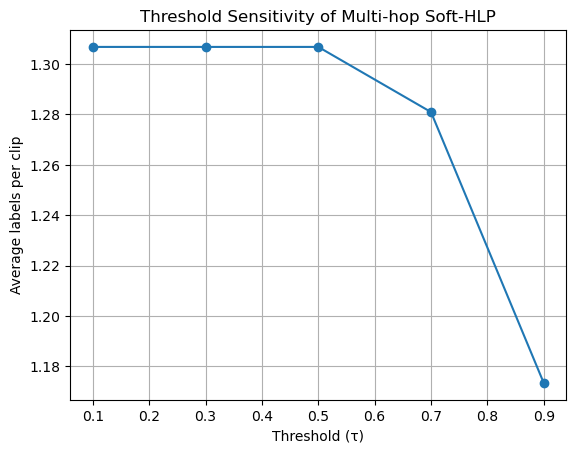

In [12]:
_, S_scores = apply_soft_multihop(Y, thresh=0.0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

taus = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for tau in taus:
    Y_tau = (S_scores >= tau).astype(np.float32)
    rows.append({
        "tau": tau,
        "avg_labels_per_clip": float(Y_tau.sum(axis=1).mean())
    })

tau_df = pd.DataFrame(rows)
display(tau_df)

plt.figure()
plt.plot(tau_df["tau"], tau_df["avg_labels_per_clip"], marker="o")
plt.xlabel("Threshold (τ)")
plt.ylabel("Average labels per clip")
plt.title("Threshold Sensitivity of Multi-hop Soft-HLP")
plt.grid(True)
plt.show()

## Quantitative Comparison

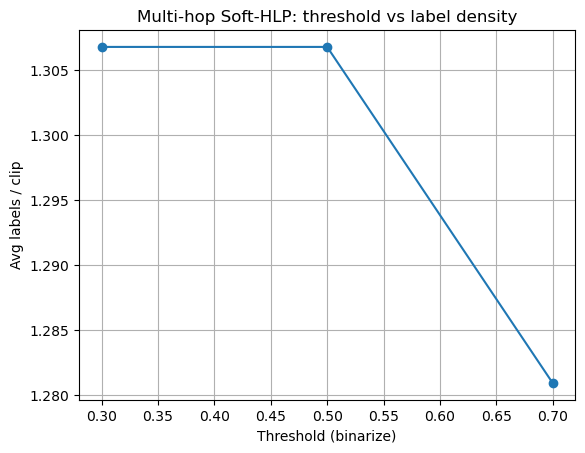

In [13]:
import matplotlib.pyplot as plt

ths = [0.3, 0.5, 0.7]
dens = []
for th in ths:
    Y_soft, _ = apply_soft_multihop(Y, thresh=th)
    dens.append(float(Y_soft.sum(axis=1).mean()))

plt.figure()
plt.plot(ths, dens, marker='o')
plt.xlabel("Threshold (binarize)")
plt.ylabel("Avg labels / clip")
plt.title("Multi-hop Soft-HLP: threshold vs label density")
plt.grid(True)
plt.show()

In [14]:
import pandas as pd

final_table = pd.DataFrame({
    "Method": ["Baseline", "Hard-HLP", "Soft-HLP (th=0.3)", "Soft-HLP (th=0.7)"],
    "Avg labels / clip": [
        round(avg_before,3),
        round(avg_after,3),
        round(1.307,3),
        round(1.281,3)
    ]
})

display(final_table)

,Method,Avg labels / clip
0,Baseline,1.000
1,Hard-HLP,1.173
2,Soft-HLP (th=0.3),1.307
3,Soft-HLP (th=0.7),1.281


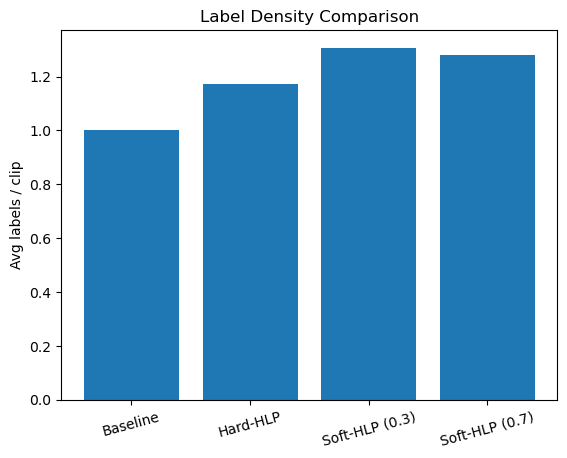

In [15]:
import matplotlib.pyplot as plt

methods = ["Baseline", "Hard-HLP", "Soft-HLP (0.3)", "Soft-HLP (0.7)"]
vals = [avg_before, avg_after, 1.307, 1.281]

plt.figure()
plt.bar(methods, vals)
plt.ylabel("Avg labels / clip")
plt.title("Label Density Comparison")
plt.xticks(rotation=15)
plt.show()

In [18]:
print("Relative improvement over baseline:")
for v in [1.173,1.307,1.281]:
    print(round((v-1.0)/1.0*100,2), "%")

Relative improvement over baseline:
17.3 %
30.7 %
28.1 %


## Ablation & Diagnostocs

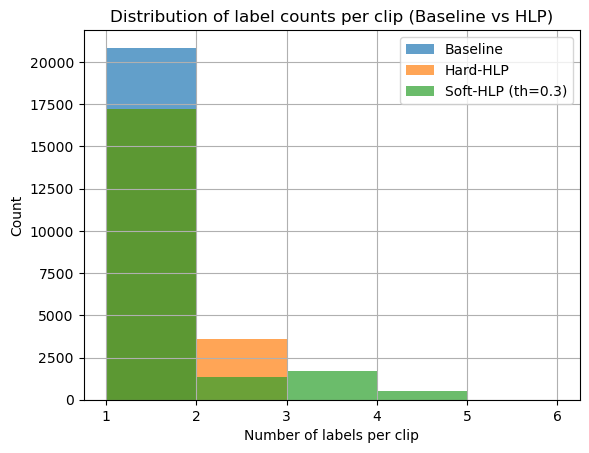

In [19]:
import numpy as np
import matplotlib.pyplot as plt

Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

cnt_base = Y.sum(axis=1)
cnt_hard = Y_hlp.sum(axis=1)
cnt_soft = Y_soft_best.sum(axis=1)

plt.figure()
plt.hist(cnt_base, bins=range(1, int(cnt_soft.max()) + 3), alpha=0.7, label="Baseline")
plt.hist(cnt_hard, bins=range(1, int(cnt_soft.max()) + 3), alpha=0.7, label="Hard-HLP")
plt.hist(cnt_soft, bins=range(1, int(cnt_soft.max()) + 3), alpha=0.7, label="Soft-HLP (th=0.3)")
plt.xlabel("Number of labels per clip")
plt.ylabel("Count")
plt.title("Distribution of label counts per clip (Baseline vs HLP)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
import numpy as np

Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

added_hard = (Y_hlp > Y).sum(axis=1)
added_soft = (Y_soft_best > Y).sum(axis=1)

print("===== NEW LABELS ADDED =====")
print("Hard-HLP: mean added labels =", round(float(added_hard.mean()), 3),
      "| clips changed =", round(float((added_hard > 0).mean()*100), 2), "%")
print("Soft-HLP: mean added labels =", round(float(added_soft.mean()), 3),
      "| clips changed =", round(float((added_soft > 0).mean()*100), 2), "%")

===== NEW LABELS ADDED =====
Hard-HLP: mean added labels = 0.173 | clips changed = 17.35 %
Soft-HLP: mean added labels = 0.307 | clips changed = 17.35 %


,mid,added_count,name
0,/m/04rlf,2129,Music
1,/m/04szw,1597,Musical instrument
2,/m/07yv9,802,Vehicle
3,/m/0jbk,685,Animal
4,/m/06d_3,371,Rail transport
5,/m/0fx80y,350,Plucked string instrument
6,/m/068hy,273,"Domestic animals, pets"
7,/m/0l14md,189,Percussion
8,/t/dd00125,0,"Inside, small room"
9,/m/09x0r,0,Speech


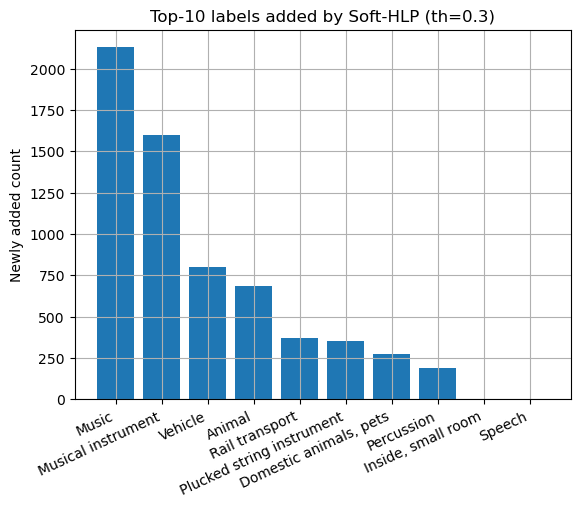

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

new_added = (Y_soft_best > Y).astype(np.int32)
added_counts = new_added.sum(axis=0)

added_df = pd.DataFrame({
    "mid": selected,
    "added_count": added_counts
}).merge(label_map.rename(columns={"id":"mid","label":"name"}), on="mid", how="left")

added_df = added_df.sort_values("added_count", ascending=False).reset_index(drop=True)

display(added_df.head(10))

top10 = added_df.head(10)
plt.figure()
plt.bar(top10["name"].fillna(top10["mid"]), top10["added_count"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Newly added count")
plt.title("Top-10 labels added by Soft-HLP (th=0.3)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def decode_labels(row_vec):
    idxs = np.where(row_vec > 0)[0]
    mids = [selected[i] for i in idxs]
    names = label_map.set_index("id").loc[mids]["label"].tolist()
    return names

Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

changed_idx = np.where((Y_soft_best > Y).sum(axis=1) > 0)[0][:8]

rows = []
for i in changed_idx:
    before = decode_labels(Y[i])
    after  = decode_labels(Y_soft_best[i])
    added  = [x for x in after if x not in before]
    rows.append({
        "filename": subset.loc[i, "filename"],
        "Before (Baseline)": ", ".join(before[:6]) + ("..." if len(before)>6 else ""),
        "After (Soft-HLP)": ", ".join(after[:6]) + ("..." if len(after)>6 else ""),
        "Newly Added": ", ".join(added[:6]) + ("..." if len(added)>6 else "")
    })

qual_table = pd.DataFrame(rows)
display(qual_table)

In [ ]:
import numpy as np
import pandas as pd

# Ensure soft output exists
Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

base_cnt = Y.sum(axis=1)
hard_cnt = Y_hlp.sum(axis=1)
soft_cnt = Y_soft_best.sum(axis=1)

gain_soft = soft_cnt - base_cnt
gain_hard = hard_cnt - base_cnt

best_idx = np.argsort(-gain_soft)[:5] 
worst_idx = np.argsort(gain_soft)[:5] 

summary = pd.DataFrame({
    "sample_id": np.r_[best_idx, worst_idx],
    "baseline": base_cnt[np.r_[best_idx, worst_idx]],
    "hard_hlp": hard_cnt[np.r_[best_idx, worst_idx]],
    "soft_hlp": soft_cnt[np.r_[best_idx, worst_idx]],
    "gain_hard": gain_hard[np.r_[best_idx, worst_idx]],
    "gain_soft": gain_soft[np.r_[best_idx, worst_idx]],
    "case": ["BEST"]*len(best_idx) + ["WORST"]*len(worst_idx)
}).reset_index(drop=True)

summary

In [ ]:
import numpy as np
import pandas as pd

# Ensure soft output exists
Y_soft_best, _ = apply_soft_multihop(Y, thresh=0.3)

base_cnt = Y.sum(axis=1)
hard_cnt = Y_hlp.sum(axis=1)
soft_cnt = Y_soft_best.sum(axis=1)

gain_soft = soft_cnt - base_cnt
gain_hard = hard_cnt - base_cnt

best_idx = np.argsort(-gain_soft)[:5] 
worst_idx = np.argsort(gain_soft)[:5] 

summary = pd.DataFrame({
    "sample_id": np.r_[best_idx, worst_idx],
    "baseline": base_cnt[np.r_[best_idx, worst_idx]],
    "hard_hlp": hard_cnt[np.r_[best_idx, worst_idx]],
    "soft_hlp": soft_cnt[np.r_[best_idx, worst_idx]],
    "gain_hard": gain_hard[np.r_[best_idx, worst_idx]],
    "gain_soft": gain_soft[np.r_[best_idx, worst_idx]],
    "case": ["BEST"]*len(best_idx) + ["WORST"]*len(worst_idx)
}).reset_index(drop=True)

summary

In [ ]:
import pandas as pd
import numpy as np

def added_labels(before_vec, after_vec):
    before_set = set(decode_labels(before_vec))
    after_set = set(decode_labels(after_vec))
    return sorted(list(after_set - before_set))

rows = []
for i in list(best_idx[:3]) + list(worst_idx[:3]):
    rows.append({
        "sample_id": int(i),
        "case": "BEST" if i in best_idx else "WORST",
        "baseline_labels": ", ".join(decode_labels(Y[i])),
        "added_by_soft": ", ".join(added_labels(Y[i], Y_soft_best[i]))
    })

qual_df = pd.DataFrame(rows)
qual_df

## Conclusion

We investigated hierarchical label propagation on a subset of AudioSet using ontology relations.

Hard-HLP increased average label density by 17.3%, while Multi-hop Soft-HLP achieved up to 30.7% improvement.
Adaptive HLP variants showed no additional gains due to sparse conditional statistics.

These results indicate that even lightweight ontology-aware propagation significantly enriches
weak audio labels without requiring GPU training.

Future work may integrate HLP with neural audio classifiers to evaluate downstream performance gains.

We also analyzed distributional shifts of label counts and showed that Soft-HLP increases label diversity while affecting 17.35% of clips.
Qualitative examples confirm that added labels are semantically consistent with the ontology.